In [19]:
import re
import unicodedata
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from IPython.display import display, Markdown

DB_PATH = "/home/cdo/Downloads/CEV_db/cev_compiled.sqlite"
OUTPUT_DIR = Path("/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

engine = create_engine(f"sqlite:///{DB_PATH}")

sql = """
SELECT
    document_id,
    tipo_vivienda
FROM descripcion_general
WHERE tipo_vivienda IS NOT NULL
  AND TRIM(tipo_vivienda) <> '';
"""

with engine.connect() as conn:
    df_tipo = pd.read_sql_query(text(sql), conn)

print(f"Registros con tipo_vivienda válido: {len(df_tipo):,}")
display(df_tipo.head())

Registros con tipo_vivienda válido: 228,973


,document_id,tipo_vivienda
0,f8315b2026,"Departamento, Piso 2, Departamento 201"
1,4d97c72026,"Departamento, Piso 2, Departamento 202"
2,12d3512026,"Departamento, Piso 2, Departamento 203"
3,99374b2026,"Departamento, Piso 2, Departamento 204"
4,c5ff1f2026,"Departamento, Piso 2, Departamento 205"


In [20]:
def normalize_text(text):
    """
    Normaliza texto para análisis:
    - minúsculas
    - elimina tildes
    - elimina signos
    - normaliza espacios
    """
    if pd.isna(text):
        return ""

    text = str(text).lower().strip()

    # Quitar tildes
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))

    # Reemplazar separadores por espacio
    text = re.sub(r"[/,.;:()\-–_]+", " ", text)

    # Mantener letras, números y espacios
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Espacios múltiples
    text = re.sub(r"\s+", " ", text).strip()

    return text


df_tipo["tipo_vivienda_norm"] = df_tipo["tipo_vivienda"].apply(normalize_text)

display(df_tipo.head(20))

,document_id,tipo_vivienda,tipo_vivienda_norm
0,f8315b2026,"Departamento, Piso 2, Departamento 201",departamento piso 2 departamento 201
1,4d97c72026,"Departamento, Piso 2, Departamento 202",departamento piso 2 departamento 202
2,12d3512026,"Departamento, Piso 2, Departamento 203",departamento piso 2 departamento 203
3,99374b2026,"Departamento, Piso 2, Departamento 204",departamento piso 2 departamento 204
4,c5ff1f2026,"Departamento, Piso 2, Departamento 205",departamento piso 2 departamento 205
5,e706b72026,"Departamento, Piso 2, Departamento 206",departamento piso 2 departamento 206
6,dd34512026,"Departamento, Piso 3, Departamento 301",departamento piso 3 departamento 301
7,cfe2a72026,"Departamento, Piso 3, Departamento 302",departamento piso 3 departamento 302
8,a9683e2026,"Departamento, Piso 3, Departamento 303",departamento piso 3 departamento 303
9,a4e7b72026,"Departamento, Piso 3, Departamento 304",departamento piso 3 departamento 304


In [21]:
freq_tipos_originales = (
    df_tipo["tipo_vivienda"]
    .value_counts(dropna=False)
    .reset_index()
)

freq_tipos_originales.columns = ["tipo_vivienda", "n"]

display(freq_tipos_originales.head(50))

freq_tipos_originales.to_csv(
    OUTPUT_DIR / "frecuencia_tipo_vivienda_original.csv",
    index=False
)

,tipo_vivienda,n
0,Duplex,302
1,"Casa Pareada / Continua, M1 - Pareada 2 pisos,...",234
2,departamento tipo,173
3,"Casa Pareada / Continua, Vivienda Pareada Tipo...",162
4,"Casa Pareada / Continua, 2 pisos - 2 dorm pare...",122
5,"Casa Pareada / Continua, casa pareada tipo, ma...",79
6,"Casa Pareada / Continua, Tipo A, Lote 5E-4, Mz...",72
7,"Pareadas, Tipo A",67
8,"Departamento, VISTA MONTE SARMIENTO 2, Punta",56
9,"Casa Pareada / Continua, Vivienda Base, Lote 3...",56


In [22]:
STOPWORDS = {
    "de", "del", "la", "las", "el", "los",
    "y", "en", "a", "al", "con", "sin",
    "tipo", "vivienda", "modelo", "proyecto",
    "manzana", "mz", "lote", "piso",
    "n", "no", "num", "numero",
    "dorm", "dormitorio", "dormitorios",
}

def tokenize(text):
    tokens = normalize_text(text).split()
    tokens = [
        token for token in tokens
        if token not in STOPWORDS
        and len(token) >= 2
        and not token.isnumeric()
    ]
    return tokens


df_tipo["tokens"] = df_tipo["tipo_vivienda"].apply(tokenize)

display(df_tipo[["tipo_vivienda", "tipo_vivienda_norm", "tokens"]].head(20))

,tipo_vivienda,tipo_vivienda_norm,tokens
0,"Departamento, Piso 2, Departamento 201",departamento piso 2 departamento 201,"[departamento, departamento]"
1,"Departamento, Piso 2, Departamento 202",departamento piso 2 departamento 202,"[departamento, departamento]"
2,"Departamento, Piso 2, Departamento 203",departamento piso 2 departamento 203,"[departamento, departamento]"
3,"Departamento, Piso 2, Departamento 204",departamento piso 2 departamento 204,"[departamento, departamento]"
4,"Departamento, Piso 2, Departamento 205",departamento piso 2 departamento 205,"[departamento, departamento]"
5,"Departamento, Piso 2, Departamento 206",departamento piso 2 departamento 206,"[departamento, departamento]"
6,"Departamento, Piso 3, Departamento 301",departamento piso 3 departamento 301,"[departamento, departamento]"
7,"Departamento, Piso 3, Departamento 302",departamento piso 3 departamento 302,"[departamento, departamento]"
8,"Departamento, Piso 3, Departamento 303",departamento piso 3 departamento 303,"[departamento, departamento]"
9,"Departamento, Piso 3, Departamento 304",departamento piso 3 departamento 304,"[departamento, departamento]"


In [23]:
all_tokens = []

for tokens in df_tipo["tokens"]:
    all_tokens.extend(tokens)

word_counts = Counter(all_tokens)

df_word_counts = (
    pd.DataFrame(word_counts.items(), columns=["palabra", "n"])
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

display(df_word_counts.head(50))

df_word_counts.to_csv(
    OUTPUT_DIR / "histograma_palabras_tipo_vivienda.csv",
    index=False
)

,palabra,n
0,departamento,176038
1,casa,90901
2,pareada,54115
3,continua,48017
4,depto,42176
5,aislada,31574
6,torre,22999
7,edificio,22838
8,dp,22702
9,lt,15554


**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/histograma_palabras_tipo_vivienda.png`

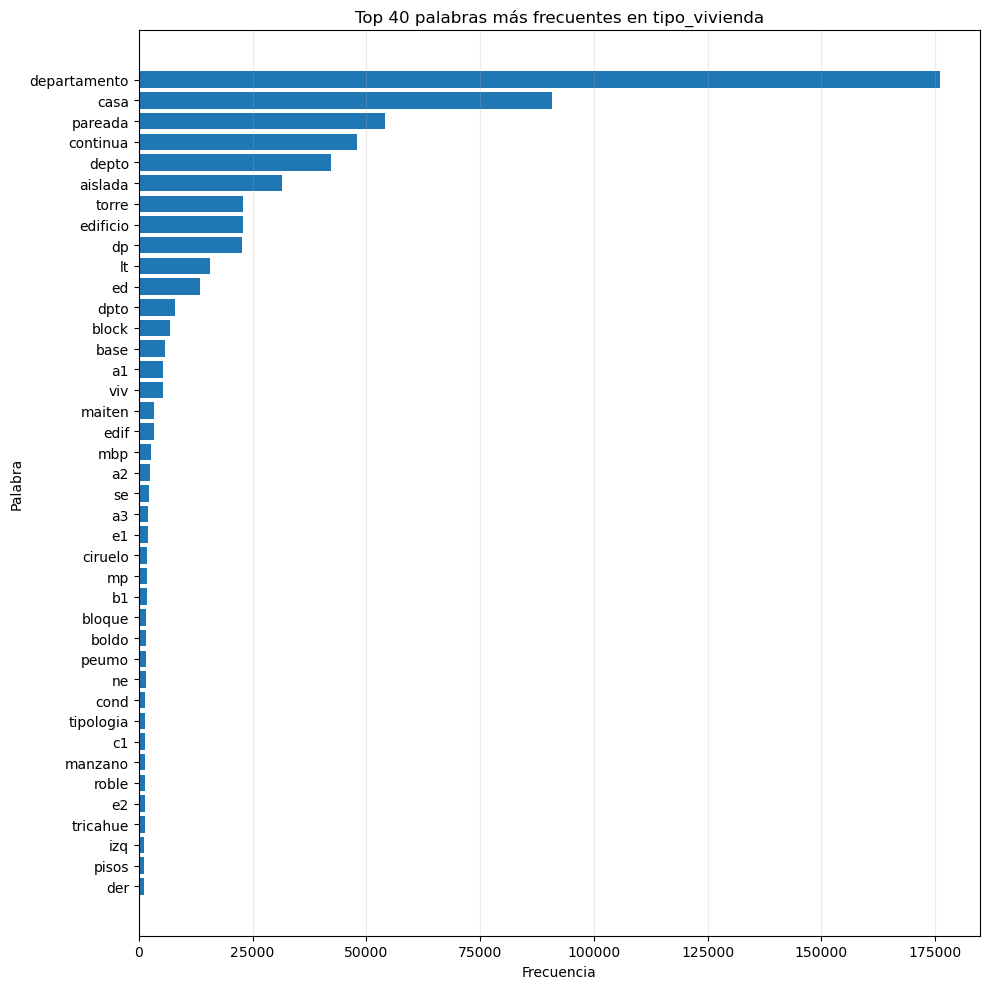

In [24]:
TOP_N = 40

plot_df = df_word_counts.head(TOP_N).sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))

ax.barh(plot_df["palabra"], plot_df["n"])

ax.set_title(f"Top {TOP_N} palabras más frecuentes en tipo_vivienda")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Palabra")
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()

out_path = OUTPUT_DIR / "histograma_palabras_tipo_vivienda.png"
fig.savefig(out_path, dpi=180)

display(Markdown(f"**Figura guardada:** `{out_path}`"))
plt.show()

In [25]:
def make_ngrams(tokens, n=2):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


all_bigrams = []

for tokens in df_tipo["tokens"]:
    all_bigrams.extend(make_ngrams(tokens, n=2))

bigram_counts = Counter(all_bigrams)

df_bigram_counts = (
    pd.DataFrame(bigram_counts.items(), columns=["bigrama", "n"])
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

display(df_bigram_counts.head(50))

df_bigram_counts.to_csv(
    OUTPUT_DIR / "histograma_bigramas_tipo_vivienda.csv",
    index=False
)

,bigrama,n
0,casa pareada,48424
1,pareada continua,47996
2,casa aislada,31161
3,departamento departamento,22724
4,departamento edificio,18582
5,departamento torre,17546
6,departamento depto,14995
7,edificio depto,7825
8,continua lt,6026
9,ed dp,4778


**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/histograma_bigramas_tipo_vivienda.png`

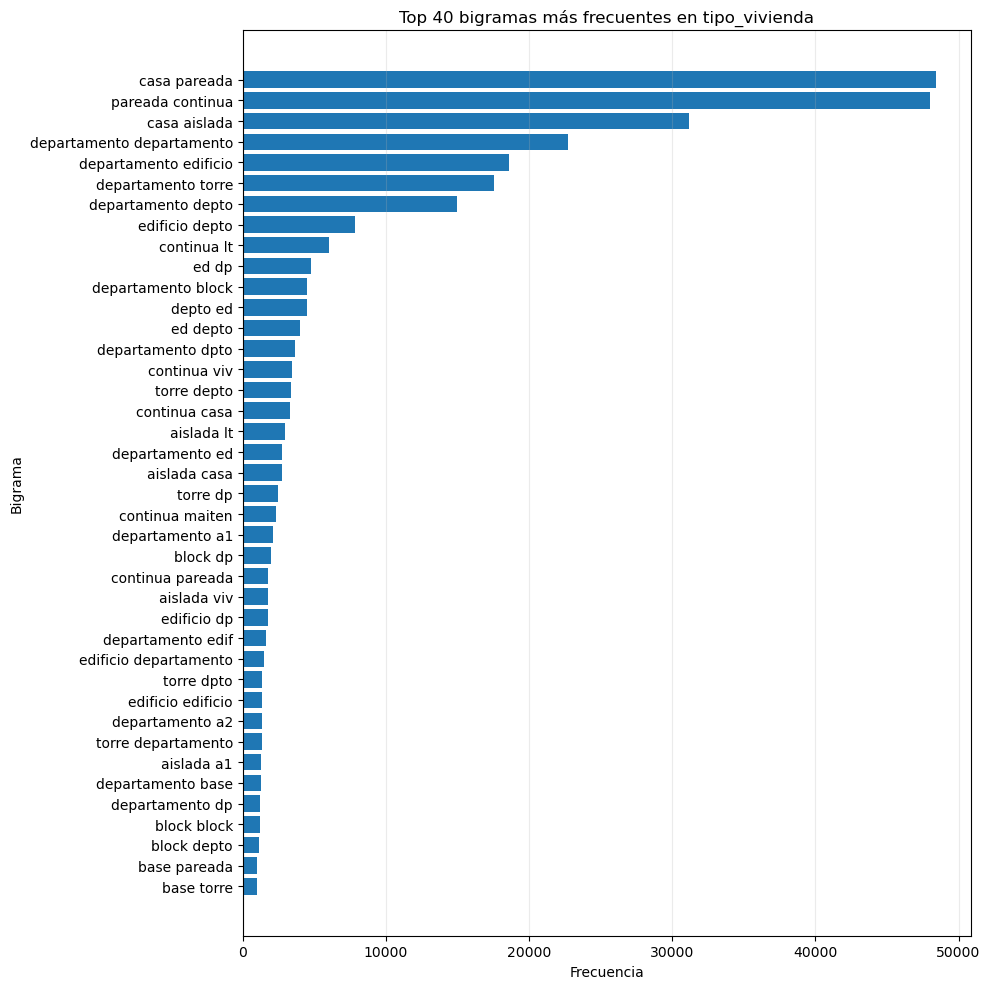

In [26]:
TOP_N = 40

plot_df = df_bigram_counts.head(TOP_N).sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))

ax.barh(plot_df["bigrama"], plot_df["n"])

ax.set_title(f"Top {TOP_N} bigramas más frecuentes en tipo_vivienda")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Bigrama")
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()

out_path = OUTPUT_DIR / "histograma_bigramas_tipo_vivienda.png"
fig.savefig(out_path, dpi=180)

display(Markdown(f"**Figura guardada:** `{out_path}`"))
plt.show()

In [27]:
all_trigrams = []

for tokens in df_tipo["tokens"]:
    all_trigrams.extend(make_ngrams(tokens, n=3))

trigram_counts = Counter(all_trigrams)

df_trigram_counts = (
    pd.DataFrame(trigram_counts.items(), columns=["trigrama", "n"])
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

display(df_trigram_counts.head(50))

df_trigram_counts.to_csv(
    OUTPUT_DIR / "histograma_trigramas_tipo_vivienda.csv",
    index=False
)

,trigrama,n
0,casa pareada continua,47950
1,pareada continua lt,6026
2,departamento edificio depto,5798
3,departamento depto ed,4464
4,pareada continua viv,3466
5,pareada continua casa,3308
6,depto ed depto,3235
7,casa aislada lt,2917
8,departamento torre depto,2695
9,casa aislada casa,2679


**Figura guardada:** `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/histograma_trigramas_tipo_vivienda.png`

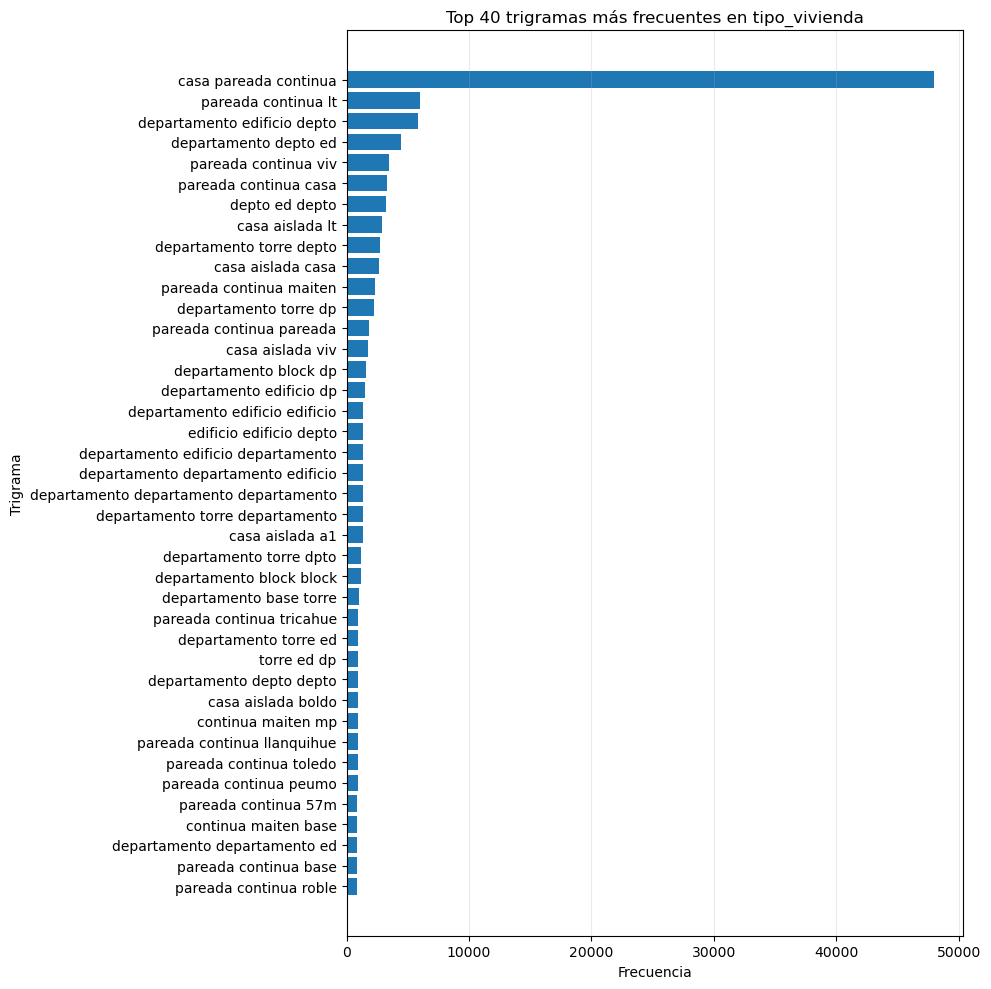

In [28]:
TOP_N = 40

plot_df = df_trigram_counts.head(TOP_N).sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))

ax.barh(plot_df["trigrama"], plot_df["n"])

ax.set_title(f"Top {TOP_N} trigramas más frecuentes en tipo_vivienda")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Trigrama")
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()

out_path = OUTPUT_DIR / "histograma_trigramas_tipo_vivienda.png"
fig.savefig(out_path, dpi=180)

display(Markdown(f"**Figura guardada:** `{out_path}`"))
plt.show()

In [29]:
KEYWORDS = [
    "casa",
    "departamento",
    "depto",
    "duplex",
    "pareada",
    "pareado",
    "continua",
    "aislada",
    "aislado",
    "condominio",
    "edificio",
    "torre",
]

keyword_rows = []

for keyword in KEYWORDS:
    mask = df_tipo["tipo_vivienda_norm"].str.contains(rf"\b{keyword}\b", regex=True, na=False)

    keyword_rows.append({
        "keyword": keyword,
        "n_registros": int(mask.sum()),
        "pct_registros": 100 * mask.mean(),
        "ejemplos": df_tipo.loc[mask, "tipo_vivienda"].drop_duplicates().head(10).tolist(),
    })

df_keyword_summary = pd.DataFrame(keyword_rows).sort_values("n_registros", ascending=False)

display(df_keyword_summary)

,keyword,n_registros,pct_registros,ejemplos
1,departamento,149247,65.181048,"[Departamento, Piso 2, Departamento 201, Depar..."
0,casa,78948,34.479174,"[Casa Aislada, Albañileria 1 piso, MZ 1, LOTE ..."
4,pareada,47976,20.952689,"[Casa Pareada / Continua, A, Mz.A, Lt. 8, Casa..."
6,continua,47950,20.941334,"[Casa Pareada / Continua, A, Mz.A, Lt. 8, Casa..."
2,depto,35750,15.613195,"[Departamento, Piso 1, Depto 201A, Departament..."
7,aislada,31025,13.549632,"[Casa Aislada, Albañileria 1 piso, MZ 1, LOTE ..."
11,torre,22272,9.726911,"[Departamento, DEPARTAMENTOS, Torre 1 Dpto 101..."
10,edificio,20863,9.111555,"[Departamento, Edificio 3, E3, Departamento 10..."
3,duplex,966,0.421884,"[Duplex, Departamento, Departamento Duplex, To..."
9,condominio,613,0.267717,"[Departamento, condominio 1, 111, Departamento..."


In [30]:
keyword = "pareada"

mask = df_tipo["tipo_vivienda_norm"].str.contains(rf"\b{keyword}\b", regex=True, na=False)

ejemplos_keyword = (
    df_tipo.loc[mask, "tipo_vivienda"]
    .value_counts()
    .reset_index()
)

ejemplos_keyword.columns = ["tipo_vivienda", "n"]

display(ejemplos_keyword.head(100))

,tipo_vivienda,n
0,"Casa Pareada / Continua, M1 - Pareada 2 pisos,...",234
1,"Casa Pareada / Continua, Vivienda Pareada Tipo...",162
2,"Casa Pareada / Continua, 2 pisos - 2 dorm pare...",122
3,"Casa Pareada / Continua, casa pareada tipo, ma...",79
4,"Casa Pareada / Continua, Tipo A, Lote 5E-4, Mz...",72
...,...,...
95,"Casa Pareada / Continua, TIPO B DISCAPACIDAD, MZ",14
96,"Casa Pareada / Continua, Lote 8 Tipo 66, 66 Lo...",14
97,"Casa Pareada / Continua, Lote 4 Tipo 61, 61 Lo...",14
98,"Casa Pareada / Continua, A1, Vivienda Tipo A1 ...",14


In [14]:
def clasificar_tipo_inmueble(tipo_vivienda_norm):
    """
    Clasifica el tipo de inmueble en:
    - 'casa_pareada': casa pareada/pareado, continua
    - 'casa_aislada': casa aislada/aislado
    - 'depto': departamento, depto, edificio, torre, condominio, duplex
    - None: si no se puede clasificar
    """
    if pd.isna(tipo_vivienda_norm) or tipo_vivienda_norm == "":
        return None
    
    texto = str(tipo_vivienda_norm).lower()
    
    # Patrones para departamento (revisar primero para que duplex sea depto, no casa)
    if any(palabra in texto for palabra in ['departamento', 'depto', 'edificio', 'torre', 'condominio', 'duplex']):
        return 'depto'
    
    # Patrones para casa pareada
    if any(palabra in texto for palabra in ['pareada', 'pareado', 'continua']):
        return 'casa_pareada'
    
    # Patrones para casa aislada
    if any(palabra in texto for palabra in ['aislada', 'aislado']):
        return 'casa_aislada'
    
    # Si menciona "casa" sin otros especificadores, se considera aislada por defecto
    if 'casa' in texto:
        return 'casa_aislada'
    
    return None


# Aplicar clasificación
df_tipo['tipo_inmueble'] = df_tipo['tipo_vivienda_norm'].apply(clasificar_tipo_inmueble)

# Mostrar distribución
display(Markdown("### Distribución de tipos de inmuebles clasificados"))
distribucion = df_tipo['tipo_inmueble'].value_counts(dropna=False)
display(distribucion)

# Mostrar ejemplos por cada categoría
display(Markdown("### Ejemplos por categoría"))
for categoria in ['casa_pareada', 'casa_aislada', 'depto']:
    ejemplos = df_tipo[df_tipo['tipo_inmueble'] == categoria]['tipo_vivienda'].drop_duplicates().head(10).tolist()
    display(Markdown(f"**{categoria}** ({distribucion.get(categoria, 0)} registros):"))
    for ej in ejemplos[:5]:
        display(Markdown(f"  - {ej}"))


### Distribución de tipos de inmuebles clasificados

tipo_inmueble
depto           149638
casa_pareada     47957
casa_aislada     31008
NaN                370
Name: count, dtype: int64

### Ejemplos por categoría

**casa_pareada** (47957 registros):

  - Casa Pareada / Continua, A, Mz.A, Lt. 8

...

  - Departamento, Piso 2, Departamento 201

  - Departamento, Piso 2, Departamento 202

  - Departamento, Piso 2, Departamento 203

  - Departamento, Piso 2, Departamento 204

  - Departamento, Piso 2, Departamento 205

In [ ]:
# Asignar indeterminado a los registros sin clasificación
n_sin_clasificar = df_tipo['tipo_inmueble'].isna().sum()
if n_sin_clasificar > 0:
    df_tipo['tipo_inmueble'] = df_tipo['tipo_inmueble'].fillna('indeterminado')
    display(Markdown(f"### {n_sin_clasificar:,} registros sin clasificación asignados a `indeterminado`"))
    display(df_tipo['tipo_inmueble'].value_counts(dropna=False))
else:
    display(Markdown("### No hay registros sin clasificación para asignar `indeterminado`"))


In [ ]:
# Actualizar la base de datos SQLite con el nuevo campo tipo_inmueble

# Primero, verificar si la columna ya existe
with engine.connect() as conn:
    result = conn.execute(text("PRAGMA table_info(descripcion_general)"))
    columns = {row[1] for row in result.fetchall()}
    
    if 'tipo_inmueble' not in columns:
        # Crear la columna
        conn.execute(text("ALTER TABLE descripcion_general ADD COLUMN tipo_inmueble TEXT"))
        conn.commit()
        display(Markdown("✓ Columna `tipo_inmueble` creada en la base de datos"))
    else:
        display(Markdown("ℹ Columna `tipo_inmueble` ya existe en la base de datos"))

# Preparar datos para actualizar
df_actualizar = df_tipo[['document_id', 'tipo_inmueble']].copy()

display(Markdown(f"### Actualizando {len(df_actualizar)} registros en la BD..."))

# Actualizar la base de datos
with engine.connect() as conn:
    for _, row in df_actualizar.iterrows():
        conn.execute(
            text("UPDATE descripcion_general SET tipo_inmueble = :tipo WHERE document_id = :doc_id"),
            {"tipo": row['tipo_inmueble'], "doc_id": row['document_id']}
        )
    conn.commit()
    display(Markdown("✓ Actualización completada"))

# Verificación: consultar los nuevos datos
sql_verificacion = """
SELECT 
    tipo_inmueble,
    COUNT(*) as n_registros,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM descripcion_general), 2) as pct_total
FROM descripcion_general
WHERE tipo_inmueble IS NOT NULL
GROUP BY tipo_inmueble
ORDER BY n_registros DESC;
"""

with engine.connect() as conn:
    df_verificacion = pd.read_sql_query(text(sql_verificacion), conn)

display(Markdown("### Verificación: distribución final en la BD"))
display(df_verificacion)

# Guardar resumen
df_verificacion.to_csv(
    OUTPUT_DIR / "resumen_tipo_inmueble_bd.csv",
    index=False
)
display(Markdown(f"✓ Resumen guardado en: `{OUTPUT_DIR / 'resumen_tipo_inmueble_bd.csv'}`"))


✓ Columna `tipo_inmueble` creada en la base de datos

### Actualizando 228603 registros en la BD...

✓ Actualización completada

### Verificación: distribución final en la BD

,tipo_inmueble,n_registros,pct_total
0,depto,149638,65.35
1,casa_pareada,47957,20.94
2,casa_aislada,31008,13.54


✓ Resumen guardado en: `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/resumen_tipo_inmueble_bd.csv`

99.82999999999998

In [16]:
# Validación: mostrar ejemplos de cada categoría desde la BD

display(Markdown("### Ejemplos de registros clasificados (desde BD)"))

for categoria in ['casa_pareada', 'casa_aislada', 'depto']:
    sql_ejemplos = f"""
    SELECT 
        document_id,
        tipo_vivienda,
        tipo_inmueble
    FROM descripcion_general
    WHERE tipo_inmueble = '{categoria}'
    LIMIT 10;
    """
    
    with engine.connect() as conn:
        df_ejemplos = pd.read_sql_query(text(sql_ejemplos), conn)
    
    display(Markdown(f"**{categoria}** ({len(df_ejemplos)} ejemplos mostrados):"))
    display(df_ejemplos)
    display(Markdown(""))


### Ejemplos de registros clasificados (desde BD)

**casa_pareada** (10 ejemplos mostrados):

,document_id,tipo_vivienda,tipo_inmueble
0,412f3c2022,"Casa Pareada / Continua, A, Mz.A, Lt. 8",casa_pareada
1,437ab82022,"Casa Pareada / Continua, A, Mz.A, Lt. 9",casa_pareada
2,8354a52022,"Casa Pareada / Continua, A, Mz.B, Lt. 4",casa_pareada
3,468f3f2022,"Casa Pareada / Continua, A, Mz.B, Lt. 8",casa_pareada
4,e73ee52022,"Casa Pareada / Continua, A, Mz.B, Lt. 9",casa_pareada
5,8a50cd2022,"Casa Pareada / Continua, A, Mz.C, Lt. 6",casa_pareada
6,7c0a732022,"Casa Pareada / Continua, A, Mz.C, Lt. 12",casa_pareada
7,b541672022,"Casa Pareada / Continua, A, Mz.D, Lt. 5",casa_pareada
8,db22d12022,"Casa Pareada / Continua, A, Mz.D, Lt. 10",casa_pareada
9,d0b1d82022,"Casa Pareada / Continua, A, Mz.D, Lt. 14",casa_pareada


**casa_aislada** (10 ejemplos mostrados):

,document_id,tipo_vivienda,tipo_inmueble
0,4cb28e2024,"Casa Aislada, Albañileria 1 piso, MZ 1, LOTE 5",casa_aislada
1,e020d62019,"Casa Aislada, Viviendda Base 44.57 m2, Manzana...",casa_aislada
2,3a11792019,"Casa Aislada, Viviendda Base 44.57 m2, Manzana...",casa_aislada
3,9bbe782019,"Casa Aislada, Viviendda Base 44.57 m2, Manzana...",casa_aislada
4,077ff12019,"Casa Aislada, Viviendda Base 44.57 m2, Manzana...",casa_aislada
5,6f19d72019,"Casa Aislada, Viviendda Base 44.57 m2, Manzana...",casa_aislada
6,b245eb2019,"Casa Aislada, Viviendda Base 44.57 m2, Manzana...",casa_aislada
7,258ef12019,"Casa Aislada, Viviendda Base 44.57 m2, Manzana...",casa_aislada
8,f47e792019,"Casa Aislada, Viviendda Base 44.57 m2, Manzana...",casa_aislada
9,4d90e32019,"Casa Aislada, Viviendda Base 44.57 m2, Manzana...",casa_aislada


**depto** (10 ejemplos mostrados):

,document_id,tipo_vivienda,tipo_inmueble
0,f8315b2026,"Departamento, Piso 2, Departamento 201",depto
1,4d97c72026,"Departamento, Piso 2, Departamento 202",depto
2,12d3512026,"Departamento, Piso 2, Departamento 203",depto
3,99374b2026,"Departamento, Piso 2, Departamento 204",depto
4,c5ff1f2026,"Departamento, Piso 2, Departamento 205",depto
5,e706b72026,"Departamento, Piso 2, Departamento 206",depto
6,dd34512026,"Departamento, Piso 3, Departamento 301",depto
7,cfe2a72026,"Departamento, Piso 3, Departamento 302",depto
8,a9683e2026,"Departamento, Piso 3, Departamento 303",depto
9,a4e7b72026,"Departamento, Piso 3, Departamento 304",depto


In [18]:
# Análisis de registros sin clasificación

display(Markdown("## Análisis de registros sin clasificación"))

# Contar sin clasificación
sin_clasificar = df_tipo[df_tipo['tipo_inmueble'].isna()]
n_sin_clasificar = len(sin_clasificar)
pct_sin_clasificar = 100 * n_sin_clasificar / len(df_tipo)

display(Markdown(f"### Total sin clasificación: **{n_sin_clasificar:,}** ({pct_sin_clasificar:.2f}%)"))

# Ver los valores originales sin clasificación
display(Markdown("### Valores de tipo_vivienda sin clasificación (primeros 100)"))
valores_sin_clasificar = (
    sin_clasificar['tipo_vivienda']
    .value_counts(dropna=False)
    .reset_index()
)
valores_sin_clasificar.columns = ['tipo_vivienda', 'n']
display(valores_sin_clasificar.head(100))

# Guardar para revisar
valores_sin_clasificar.to_csv(
    OUTPUT_DIR / "tipo_vivienda_sin_clasificar.csv",
    index=False
)
display(Markdown(f"✓ Guardado: `{OUTPUT_DIR / 'tipo_vivienda_sin_clasificar.csv'}`"))

# Análisis de patrones en los sin clasificar
display(Markdown("### Patrones en valores sin clasificación"))

# Palabras más frecuentes en los sin clasificar
from collections import Counter

all_tokens_sin_clasificar = []
for tokens in sin_clasificar['tokens']:
    all_tokens_sin_clasificar.extend(tokens)

word_counts_sin_clasificar = Counter(all_tokens_sin_clasificar)
df_words_sin_clasificar = (
    pd.DataFrame(word_counts_sin_clasificar.items(), columns=['palabra', 'n'])
    .sort_values('n', ascending=False)
    .reset_index(drop=True)
)

display(df_words_sin_clasificar.head(30))


## Análisis de registros sin clasificación

### Total sin clasificación: **370** (0.16%)

### Valores de tipo_vivienda sin clasificación (primeros 100)

,tipo_vivienda,n
0,Tipo,30
1,Tipo A,25
2,A1,25
3,Primer piso,24
4,Un piso,24
5,45 m2,24
6,B,18
7,Nogal Ampliada,18
8,C,16
9,Tipo C,14


✓ Guardado: `/home/cdo/Downloads/CEV_db/outputs_analisis_cev_jupyter/tipo_vivienda_sin_clasificar.csv`

### Patrones en valores sin clasificación

,palabra,n
0,m2,45
1,nogal,29
2,a1,25
3,un,24
4,primer,24
5,dpto,24
6,ampliada,18
7,base,15
8,viviendda,11
9,lanalhue,11
